In [ ]:
import torch
import numpy as np
from config import Config
from train_wgan import generate_sample
from utils import set_seed, plotPCbatch
from models import PointCloudAE, Generator

import warnings
warnings.filterwarnings('ignore')

data shape: (3746, 1024, 3).
number of points in one 3D cloud: 1024.
Successfully load ae!
Successfully load wgan generator!


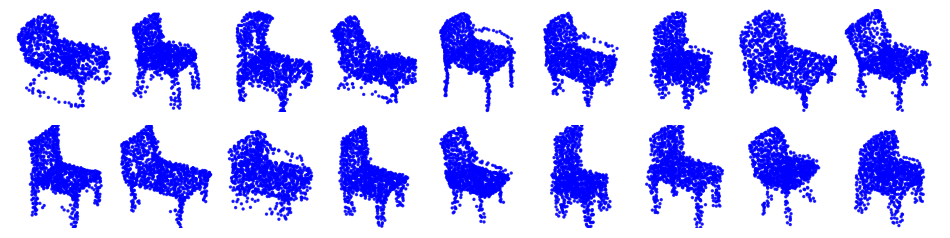

In [ ]:
if __name__ == "__main__":

    # set random seed to make results reproducible
    set_seed()

    # load config and data
    args = Config()

    data_file = args.data_dir/args.dataset
    pc_array = np.load(data_file)
    print(f"data shape: {pc_array.shape}.")

    # Assuming all models have the same size,
    point_size = pc_array.shape[1]
    print(f"number of points in one 3D cloud: {point_size}.")
    
    # load saved ae
    ae = PointCloudAE(point_size, args.latent_size).to(args.device)
    checkpoint = torch.load(args.model_dir/"ae.pt", weights_only=True)
    ae.load_state_dict(checkpoint)
    ae.eval()
    print("Successfully load ae!")

    # load saved generator
    generator = Generator().to(args.device)
    checkpoint = torch.load(args.model_dir/"wgan_g.pt", weights_only=True)
    generator.load_state_dict(checkpoint)
    generator.eval()
    print("Successfully load wgan generator!")

    #display generated samples by saved models
    sample1 = generate_sample(generator, ae, args.batch_size, args.device, latent_dim=128)
    sample2 = generate_sample(generator, ae, args.batch_size, args.device, latent_dim=128)
    plotPCbatch(sample1, sample2)